In [1]:
pip install pandas matplotlib seaborn

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 2.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.7 MB 3.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.7 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.7 MB 2.6 MB/s

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("indus_data_set.csv")
df.head()

,User ID,Timestamp,Action,Product Category,Revenue
0,abe25903-30ab-4a26-a569-604f87656d15,28-12-2024 03:26,viewed_product,Clothing,0.00
1,6475c03d-4202-470f-8ded-6f710deaff7a,07-11-2024 13:35,purchased,Clothing,392.36
2,fcca2524-5817-44a1-8697-2a9a8ff04c76,04-12-2024 0:33,added_to_cart,Sports,0.00
3,714905a0-06a3-484f-a72b-bc0787975d83,12-01-2025 12:25,purchased,Books,330.52
4,7dc8ec16-b498-4f9c-b768-e4725b9e6b73,25-11-2024 16:44,added_to_cart,Books,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 248 entries, 0 to 250
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User ID           248 non-null    str           
 1   Timestamp         248 non-null    datetime64[us]
 2   Action            248 non-null    str           
 3   Product Category  248 non-null    str           
 4   Revenue           248 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 11.6 KB


In [9]:
df.isnull().sum()

User ID             0
Timestamp           0
Action              0
Product Category    0
Revenue             0
dtype: int64

In [ ]:
# there are no null values in data set
# But sample code to handle  missing values
df['Revenue'] = df['Revenue'].fillna(0)
df['Action'] = df['Action'].fillna('unknown')
df['Product Category'] = df['Product Category'].fillna('unknown')


In [6]:
# Convert timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M', errors='coerce')

In [7]:
# Drop rows where timestamp is invalid
df = df.dropna(subset=['Timestamp'])
df.info()

<class 'pandas.DataFrame'>
Index: 248 entries, 0 to 250
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User ID           248 non-null    str           
 1   Timestamp         248 non-null    datetime64[us]
 2   Action            248 non-null    str           
 3   Product Category  248 non-null    str           
 4   Revenue           248 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 11.6 KB


In [12]:
# Create new feature with name Date
df['Date'] = df['Timestamp'].dt.date

# Create new feature with name Week
df['Week'] = df['Timestamp'].dt.to_period('W')

In [ ]:
# Getting the most popular product categories
popular_categories = df['Product Category'].value_counts()
popular_categories

Product Category
Electronics       46
Sports            43
Books             43
Home & Kitchen    39
Clothing          38
Beauty            37
unknown            2
Name: count, dtype: int64

In [16]:
# Calculating conversion rate
total_actions = len(df)
purchases = len(df[df['Action'] == 'purchased'])
conversion_rate = (purchases / total_actions) * 100
conversion_rate

28.225806451612907

In [17]:
revenue_by_category = df.groupby('Product Category')['Revenue'].sum()
revenue_by_category

Product Category
Beauty            2120.91
Books             4916.76
Clothing          4419.71
Electronics       3172.39
Home & Kitchen    1967.76
Sports            3139.59
unknown            220.36
Name: Revenue, dtype: float64

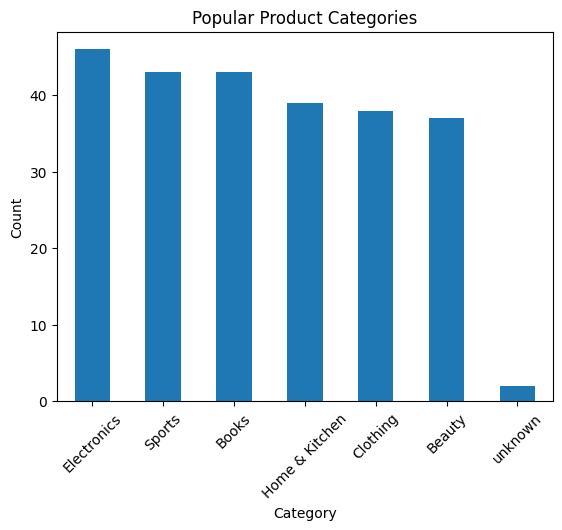

In [19]:
# Visualise user behaviour trends over time
popular_categories .plot(kind='bar')
plt.title("Popular Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

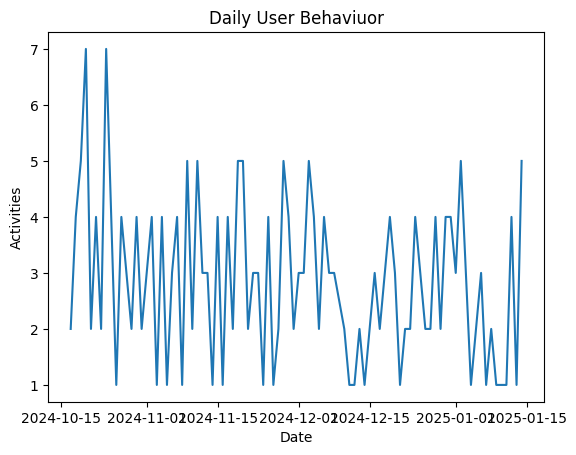

In [23]:
# Visualise User daily activity 
daily_activity = df.groupby('Date').size()
daily_activity.plot()
plt.title("Daily User Behaviuor")
plt.xlabel("Date")
plt.ylabel("Activities")
plt.show()

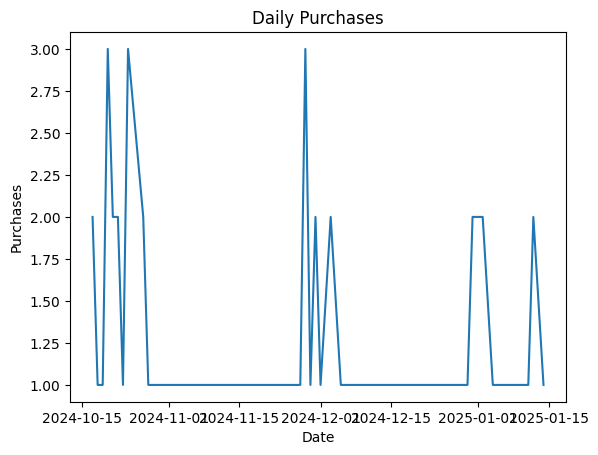

In [24]:
# Visualise purchase over time
purchases_over_time = df[df['Action'] == 'purchased'].groupby('Date').size()
purchases_over_time.plot()
plt.title("Daily Purchases")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.show()